# Balanced and Unbalanced Dynamic Geodesics

This notebook generates `fig:dynamic-unbalanced-geodesic`. It compares two lightweight numerical interpolations between **one-dimensional** Gaussian mixtures with the same total mass but swapped modal masses.

The balanced row uses entropic Sinkhorn barycenters
\[
\rho_t \approx \arg\min_\rho (1-t)\,\mathcal W^\varepsilon_2(\rho,\alpha)
+t\,\mathcal W^\varepsilon_2(\rho,\beta),
\]
so total mass is conserved and excess mass must be transported along the line. The unbalanced row uses POT's KL-relaxed unbalanced Sinkhorn barycenter, which replaces the hard marginal constraint by a finite penalty. This is not meant as a full dynamic WFR solver; it is a simple and reproducible discretization that makes the same reaction--transport intuition visible: overrepresented mass fades and missing mass is recreated.

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

for candidate in [Path.cwd(), Path.cwd() / "notebooks-figures", Path.cwd().parent / "notebooks-figures"]:
    if (candidate / "figure_style.py").exists():
        sys.path.insert(0, str(candidate.resolve()))
        break
else:
    raise RuntimeError("Could not locate figure_style.py")

import matplotlib.pyplot as plt
import numpy as np
import ot
from IPython.display import Image, display

from figure_style import (
    BLUE,
    RED,
    figure_dir,
    interp_color,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

NAME = "dynamic-unbalanced-geodesic"
OUT = figure_dir(NAME)
THUMB = Path("thumbnails") / f"{NAME}.png"
THUMB.parent.mkdir(parents=True, exist_ok=True)

## One-dimensional endpoint mixtures

The source and target have two corresponding modes on the line, but the dominant mode changes side. Balanced interpolation must move the excess left mass to the dominant right target mode. Unbalanced interpolation can instead reduce mass where it is overrepresented and recreate it near the underrepresented target mode.

In [2]:
N = 260
x = np.linspace(-3.0, 3.0, N)
dx = x[1] - x[0]


def gaussian_1d(mean, sigma):
    return np.exp(-0.5 * ((x - mean) / sigma) ** 2) / (np.sqrt(2.0 * np.pi) * sigma)


def normalize_density(z):
    # POT barycenters are computed with discrete probability vectors.
    z = np.maximum(np.asarray(z, dtype=float), 1e-300)
    return z / z.sum()


heavy = 0.88
light = 1.0 - heavy

alpha = normalize_density(
    heavy * gaussian_1d(-1.25, 0.17)
    + light * gaussian_1d(0.72, 0.20)
)
beta = normalize_density(
    light * gaussian_1d(-0.72, 0.20)
    + heavy * gaussian_1d(1.25, 0.17)
)
A = np.column_stack([alpha, beta])

M = (x[:, None] - x[None, :]) ** 2
M /= np.median(M[M > 0])

times = np.array([0.0, 0.25, 0.50, 0.75, 1.0])
REG = 0.003
REG_M = 0.14

## Balanced and unbalanced Sinkhorn barycenters

The endpoints are inserted exactly. Intermediate times are obtained as two-measure barycenters with weights `(1-t, t)`. The unbalanced barycenter is intentionally **not** renormalized: its reduced area at intermediate times is part of the reaction term being illustrated.

In [3]:
balanced = []
unbalanced = []
for t in times:
    if np.isclose(t, 0.0):
        b = alpha.copy()
        u = alpha.copy()
    elif np.isclose(t, 1.0):
        b = beta.copy()
        u = beta.copy()
    else:
        weights = np.array([1.0 - t, t])
        b = ot.bregman.barycenter(
            A,
            M,
            REG,
            weights=weights,
            numItermax=10_000,
            stopThr=1e-10,
            warn=False,
        )
        u = ot.unbalanced.barycenter_unbalanced_sinkhorn(
            A,
            M,
            reg=REG,
            reg_m=REG_M,
            weights=weights,
            numItermax=10_000,
            stopThr=1e-10,
            log=False,
            verbose=False,
        )
    balanced.append(b)
    unbalanced.append(u)

balanced = np.stack(balanced)
unbalanced = np.stack(unbalanced)

balanced_masses = balanced.sum(axis=1)
unbalanced_masses = unbalanced.sum(axis=1)

assert np.allclose(balanced_masses, 1.0, atol=5e-6)
assert np.all((0.80 < unbalanced_masses) & (unbalanced_masses <= 1.01))
assert np.all(np.isfinite(balanced))
assert np.all(np.isfinite(unbalanced))
assert np.all(unbalanced >= -1e-13)
print("balanced masses:", np.round(balanced_masses, 4))
print("unbalanced masses:", np.round(unbalanced_masses, 4))

balanced masses: [1. 1. 1. 1. 1.]
unbalanced masses: [1.     0.9289 0.8617 0.9289 1.    ]


## Rendering

Each PDF panel contains only a one-dimensional density curve, with no embedded title or axis. The manuscript arranges the row labels and time labels in LaTeX.

In [4]:
PANEL_XLIM = (-2.25, 2.25)
LINE_WIDTH = 1.28
BASELINE_WIDTH = 0.42
FILL_ALPHA = 0.30

# Convert discrete masses to density heights for plotting. Areas under the
# curves are the discrete masses up to the common grid spacing.
balanced_density = balanced / dx
unbalanced_density = unbalanced / dx
YMAX = 1.12 * max(balanced_density.max(), unbalanced_density.max())


def draw_density_panel(ax, density, t):
    color = interp_color(float(t), RED, BLUE)
    ax.fill_between(x, density, 0.0, color=color, alpha=FILL_ALPHA, linewidth=0)
    ax.plot(x, density, color=color, lw=LINE_WIDTH, solid_capstyle="round")
    ax.axhline(0.0, color="#303030", lw=BASELINE_WIDTH, solid_capstyle="butt")
    ax.set_xlim(*PANEL_XLIM)
    ax.set_ylim(0.0, YMAX)
    remove_axes(ax)


filenames = []
for row_name, row_data in [("balanced", balanced_density), ("unbalanced", unbalanced_density)]:
    for t, density in zip(times, row_data):
        fig, ax = plt.subplots(figsize=(1.42, 0.68))
        draw_density_panel(ax, density, t)
        fig.subplots_adjust(0, 0, 1, 1)
        tag = f"{row_name}-t{int(round(100 * t)):03d}.pdf"
        save_pdf(fig, OUT / tag, pad_inches=0.0)
        filenames.append(tag)
        plt.close(fig)

print("Exported", len(filenames), "PDF panels to", OUT)

Exported 10 PDF panels to /Users/gpeyre/Dropbox/github/ot4ml/latex/figures/dynamic-unbalanced-geodesic


## Thumbnail preview

The thumbnail below is only for the notebook gallery. It uses the same generated curves as the paper panels.

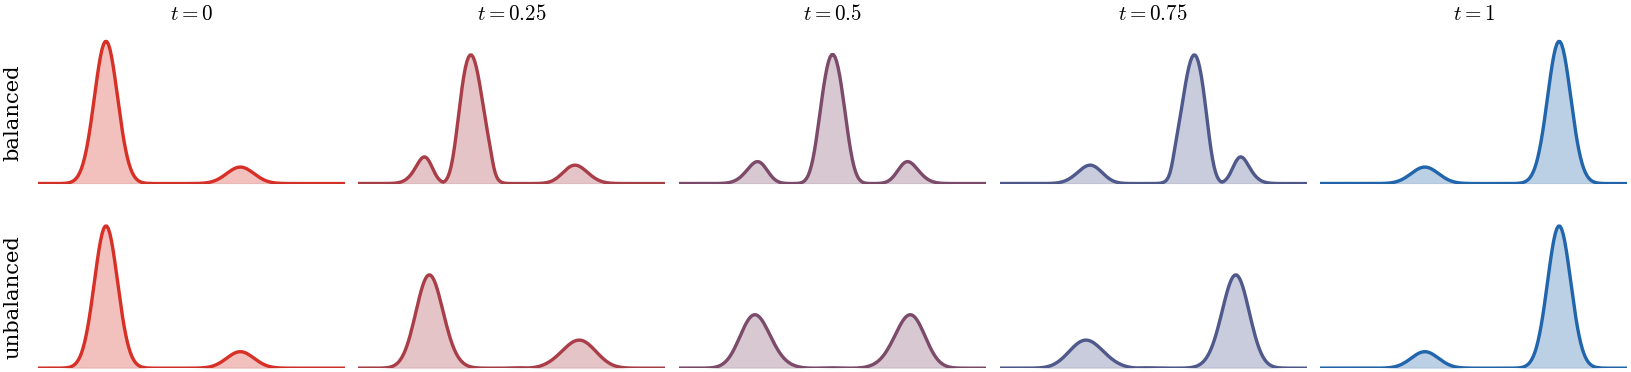

In [5]:
fig, axes = plt.subplots(2, len(times), figsize=(8.9, 2.18), sharex=True, sharey=True)
for r, (row_name, row_data) in enumerate([("balanced", balanced_density), ("unbalanced", unbalanced_density)]):
    for c, (t, density) in enumerate(zip(times, row_data)):
        ax = axes[r, c]
        draw_density_panel(ax, density, t)
        if r == 0:
            ax.set_title(rf"$t={t:.2g}$", fontsize=8, pad=2)
        if c == 0:
            ax.text(PANEL_XLIM[0] - 0.22, 0.45 * YMAX, row_name, ha="right", va="center", fontsize=8, rotation=90)
fig.subplots_adjust(wspace=0.045, hspace=0.16, left=0.055, right=0.995, top=0.86, bottom=0.03)
fig.savefig(THUMB, dpi=190, bbox_inches="tight", pad_inches=0.02)
plt.close(fig)

display(Image(filename=str(THUMB)))